<a href="https://colab.research.google.com/github/GeethmaMunasinghe/Digital_Image_Processing/blob/main/TG_2020_698.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
# Run this first to set up
import numpy as np
import cv2
import matplotlib.pyplot as plt
from google.colab import files

# Utility functions
def to_grayscale(path):
    img = cv2.imread(path)
    return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

def log_transform(img):
    c = 255 / np.log(1 + np.max(img))
    return np.array(c * np.log(1 + img.astype(np.float32)), dtype=np.uint8)

def gamma_transform(img, gamma=0.4):
    return np.array(255 * (img / 255.0) ** gamma, dtype=np.uint8)

def contrast_stretch(img):
    a, b = np.min(img), np.max(img)
    return np.array(255 * (img - a) / (b - a), dtype=np.uint8)

def negative_transform(img):
    return 255 - img

def show_images(images, titles):
    plt.figure(figsize=(15, 5))
    for i, (img, title) in enumerate(zip(images, titles)):
        plt.subplot(1, len(images), i+1)
        plt.imshow(img, cmap='gray')
        plt.title(title)
        plt.axis('off')
    plt.show()


# **Image 01**

Saving dark_img.jpg to dark_img.jpg


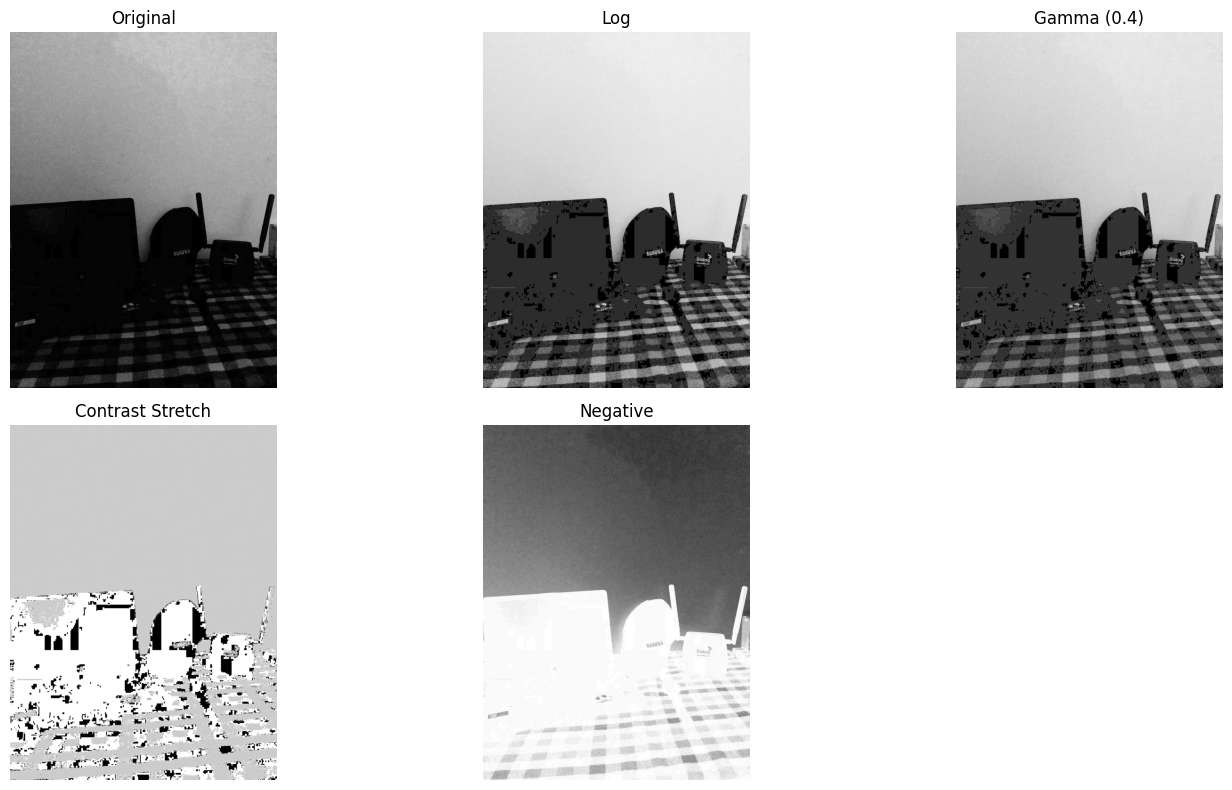

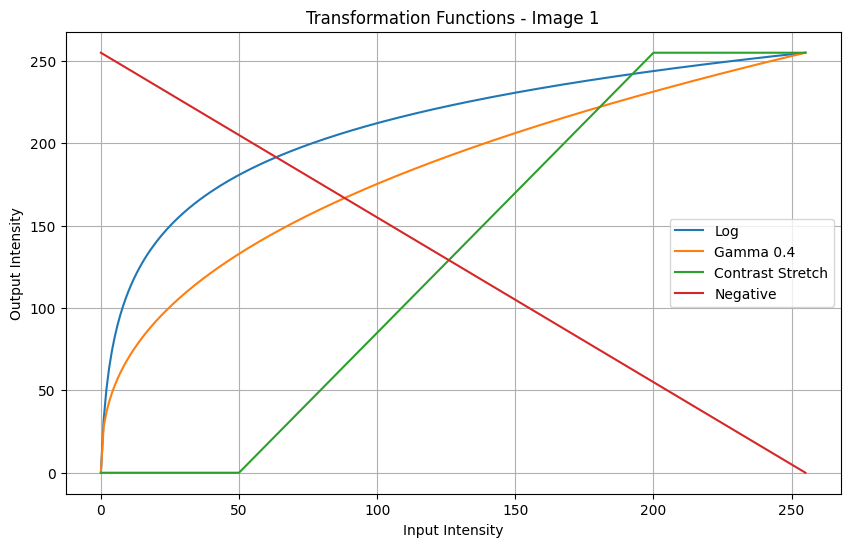

In [10]:
# Upload Image
uploaded = files.upload()

# Convert to Grayscale
def to_grayscale(image_path):
    img = cv2.imread(image_path)
    return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Log Transformation
def log_transform(image):
    c = 255 / np.log(1 + np.max(image))
    return np.array(c * np.log(1 + image), dtype=np.uint8)

# Gamma Transformation
def gamma_transform(image, gamma=1.0):
    normalized = image / 255.0
    corrected = np.power(normalized, gamma)
    return np.uint8(corrected * 255)

# Contrast Stretching
def contrast_stretch(image):
    min_val = np.min(image)
    max_val = np.max(image)
    stretched = 255 * (image - min_val) / (max_val - min_val)
    return np.uint8(stretched)

# Negative Transformation
def negative_transform(image):
    return 255 - image

# Display Multiple Images
def show_images(images, titles):
    plt.figure(figsize=(15, 8))
    for i in range(len(images)):
        plt.subplot(2, 3, i+1)
        plt.imshow(images[i], cmap='gray')
        plt.title(titles[i])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Apply transformations
img1 = to_grayscale("dark_img.jpg")

img1_log = log_transform(img1)
img1_gamma = gamma_transform(img1, gamma=0.4)
img1_contrast = contrast_stretch(img1)
img1_negative = negative_transform(img1)

# Show transformed images
show_images(
    [img1, img1_log, img1_gamma, img1_contrast, img1_negative],
    ['Original', 'Log', 'Gamma (0.4)', 'Contrast Stretch', 'Negative']
)

# Plot transformation curves
x = np.arange(0, 256)
log_curve = 255 / np.log(1 + 255) * np.log(1 + x)
gamma_curve = 255 * (x / 255.0) ** 0.4
contrast_curve = np.clip(255 * (x - 50) / (200 - 50), 0, 255)
neg_curve = 255 - x

plt.figure(figsize=(10, 6))
plt.plot(x, log_curve, label='Log')
plt.plot(x, gamma_curve, label='Gamma 0.4')
plt.plot(x, contrast_curve, label='Contrast Stretch')
plt.plot(x, neg_curve, label='Negative')
plt.title('Transformation Functions - Image 1')
plt.xlabel('Input Intensity')
plt.ylabel('Output Intensity')
plt.legend()
plt.grid(True)
plt.show()

Image 1 (Dim Room):

*   The original image is very dark due to poor lighting.
*   Gamma and Log transforms helped bring out details in the shadows.
*   Best: Gamma transform (γ=0.4) – It increased visibility without
    overexposing.

# **Image 02**

Saving light_img.jpg to light_img.jpg


<ipython-input-10-b765e51c657a>:11: RuntimeWarning: overflow encountered in scalar add
  c = 255 / np.log(1 + np.max(image))
<ipython-input-10-b765e51c657a>:11: RuntimeWarning: divide by zero encountered in log
  c = 255 / np.log(1 + np.max(image))
<ipython-input-10-b765e51c657a>:12: RuntimeWarning: divide by zero encountered in log
  return np.array(c * np.log(1 + image), dtype=np.uint8)
<ipython-input-10-b765e51c657a>:12: RuntimeWarning: invalid value encountered in multiply
  return np.array(c * np.log(1 + image), dtype=np.uint8)
<ipython-input-10-b765e51c657a>:12: RuntimeWarning: invalid value encountered in cast
  return np.array(c * np.log(1 + image), dtype=np.uint8)


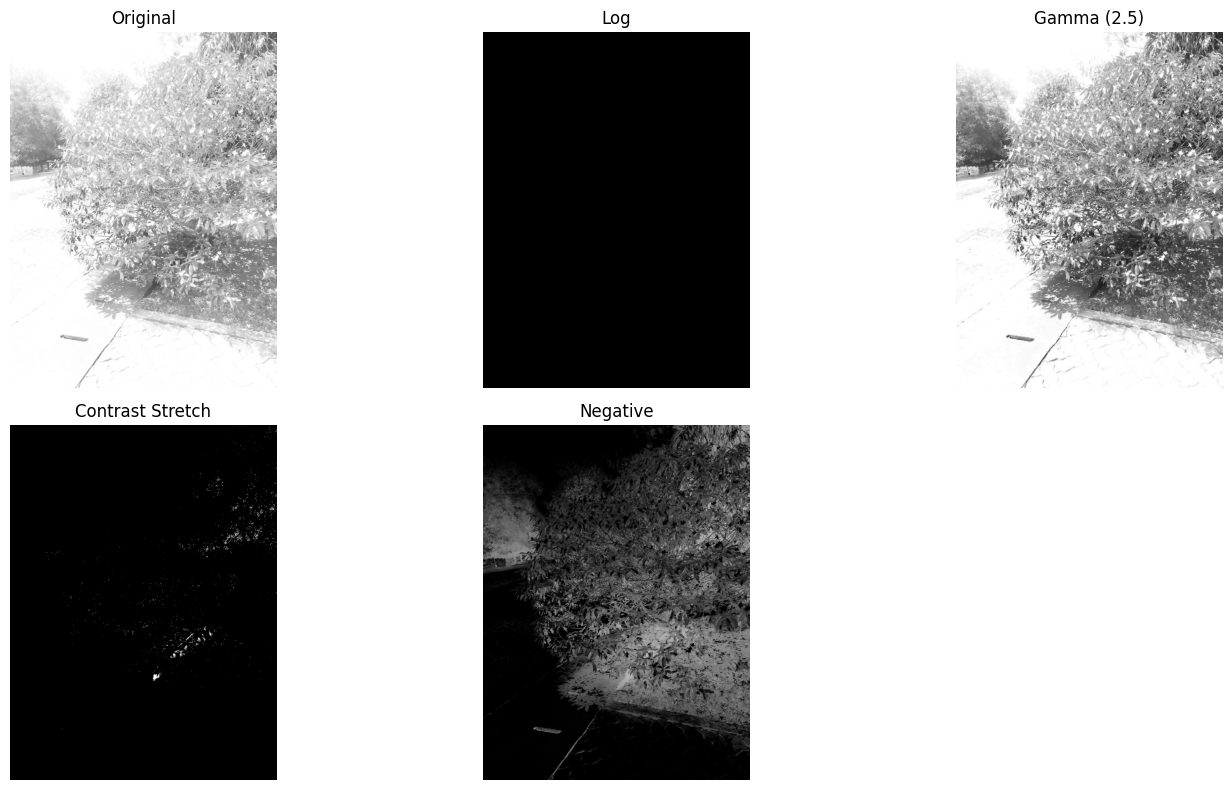

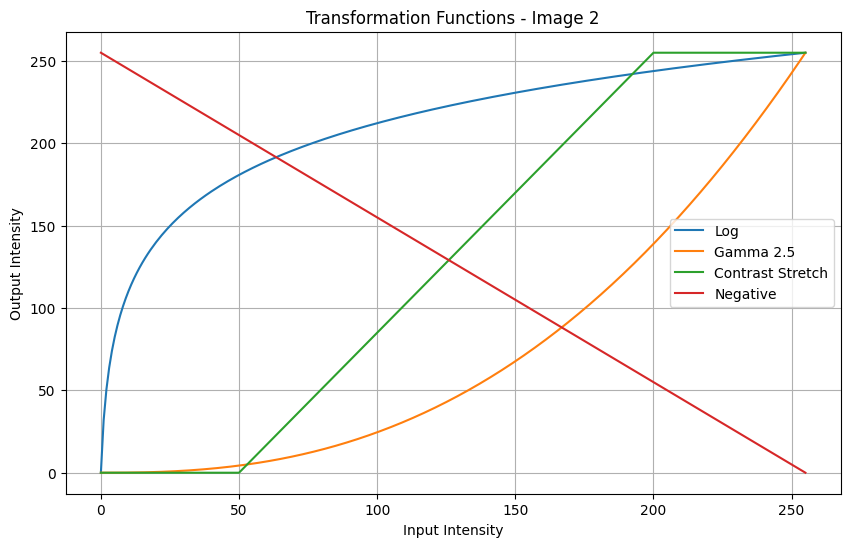

In [11]:
files.upload()
img2 = to_grayscale("light_img.jpg")

img2_log = log_transform(img2)
img2_gamma = gamma_transform(img2, gamma=2.5)
img2_contrast = contrast_stretch(img2)
img2_negative = negative_transform(img2)

show_images([img2, img2_log, img2_gamma, img2_contrast, img2_negative],
            ['Original', 'Log', 'Gamma (2.5)', 'Contrast Stretch', 'Negative'])

gamma_curve = 255 * (x / 255.0) ** 2.5

plt.figure(figsize=(10, 6))
plt.plot(x, log_curve, label='Log')
plt.plot(x, gamma_curve, label='Gamma 2.5')
plt.plot(x, contrast_curve, label='Contrast Stretch')
plt.plot(x, neg_curve, label='Negative')
plt.title('Transformation Functions - Image 2')
plt.xlabel('Input Intensity')
plt.ylabel('Output Intensity')
plt.legend()
plt.grid(True)
plt.show()

Image 2 (Facing Light Source):

*  The original image is overexposed in bright areas.
*  Gamma transform (γ=2.5) darkened highlights, recovering some detail.
*  Best: Gamma transform – It compresses highlights and balances
   exposure.

# **Image 03**

Saving transparent_img.jpg to transparent_img.jpg


<ipython-input-10-b765e51c657a>:11: RuntimeWarning: overflow encountered in scalar add
  c = 255 / np.log(1 + np.max(image))
<ipython-input-10-b765e51c657a>:11: RuntimeWarning: divide by zero encountered in log
  c = 255 / np.log(1 + np.max(image))
<ipython-input-10-b765e51c657a>:12: RuntimeWarning: divide by zero encountered in log
  return np.array(c * np.log(1 + image), dtype=np.uint8)
<ipython-input-10-b765e51c657a>:12: RuntimeWarning: invalid value encountered in multiply
  return np.array(c * np.log(1 + image), dtype=np.uint8)
<ipython-input-10-b765e51c657a>:12: RuntimeWarning: invalid value encountered in cast
  return np.array(c * np.log(1 + image), dtype=np.uint8)


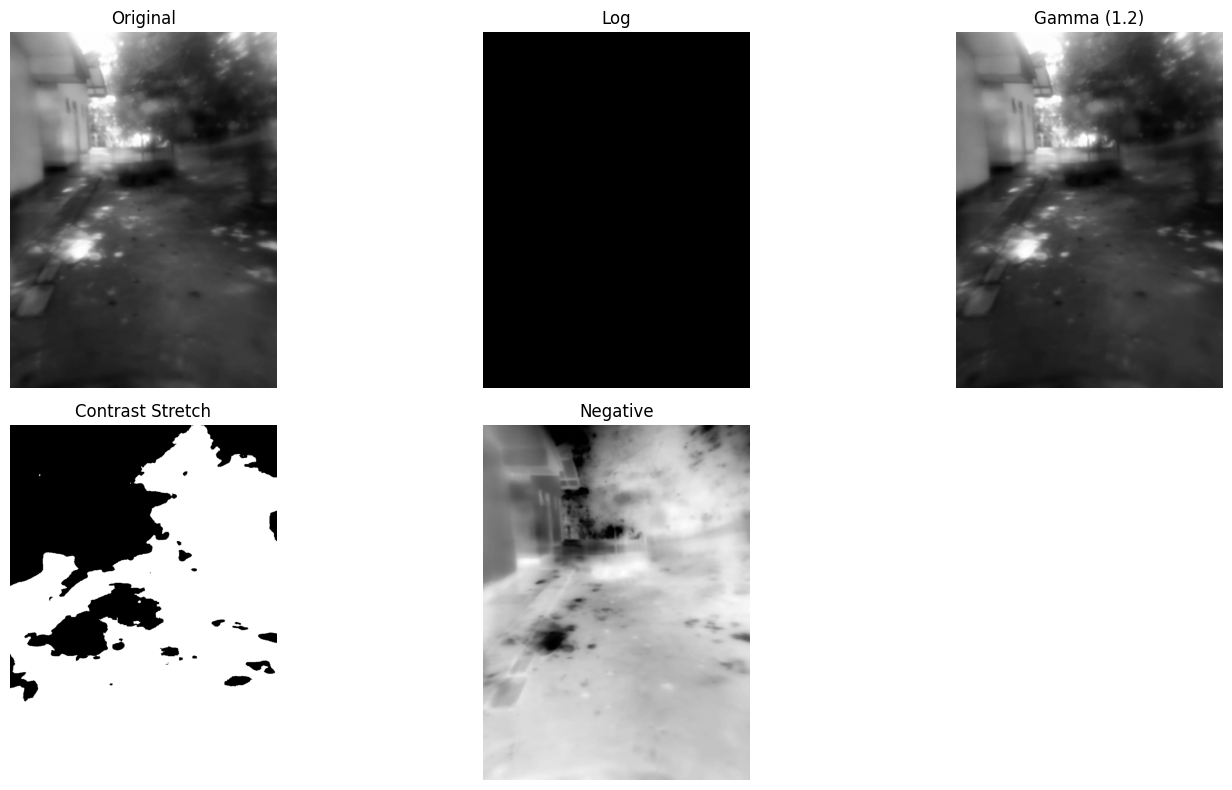

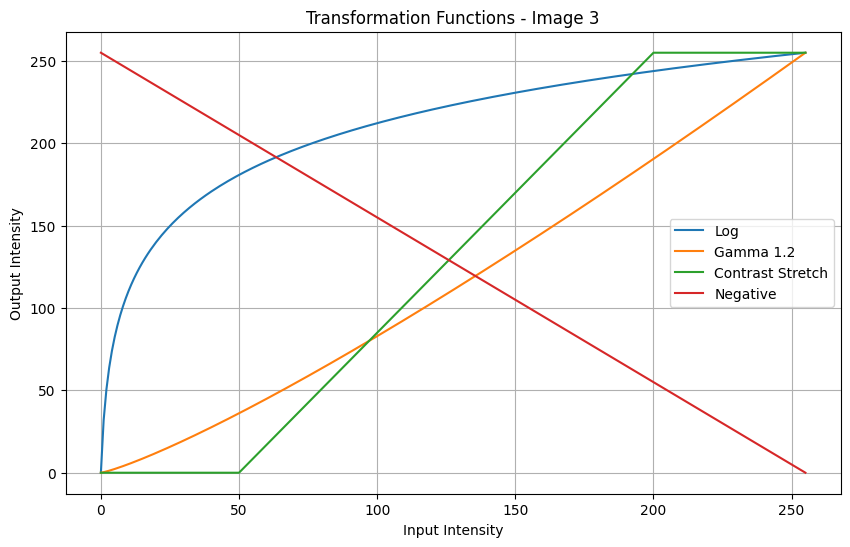

In [14]:
files.upload()  # Upload as "image3.jpg"
img3 = to_grayscale("transparent_img.jpg")

img3_log = log_transform(img3)
img3_gamma = gamma_transform(img3, gamma=1.2)
img3_contrast = contrast_stretch(img3)
img3_negative = negative_transform(img3)

show_images([img3, img3_log, img3_gamma, img3_contrast, img3_negative],
            ['Original', 'Log', 'Gamma (1.2)', 'Contrast Stretch', 'Negative'])


gamma_curve = 255 * (x / 255.0) ** 1.2

plt.figure(figsize=(10, 6))
plt.plot(x, log_curve, label='Log')
plt.plot(x, gamma_curve, label='Gamma 1.2')
plt.plot(x, contrast_curve, label='Contrast Stretch')
plt.plot(x, neg_curve, label='Negative')
plt.title('Transformation Functions - Image 3')
plt.xlabel('Input Intensity')
plt.ylabel('Output Intensity')
plt.legend()
plt.grid(True)
plt.show()

Image 3 (Plastic-covered Lens):


*   The image is hazy with low contrast.
*   Contrast stretching significantly improved clarity.
*   Best: Contrast Stretch – It boosted detail while preserving the
    overall look.